## ARIMA Model

### Data Prep

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [2]:

df = pd.read_csv('used_cars_cleaned.csv')
df['listed_date'] = pd.to_datetime(df['listed_date'])

# filter to 2018+
df = df[df['listed_date'] >= '2018-01-01']

# aggregate to monthly median asking price
data = df.set_index('listed_date').resample('MS')['price'].median()
data = data.dropna()
data = pd.DataFrame({'Price': data})
data.head()

,Price
listed_date,
2018-01-01,13260.0
2018-02-01,11985.0
2018-03-01,14992.5
2018-04-01,14995.0
2018-05-01,14988.0


### Visualize the Time Series

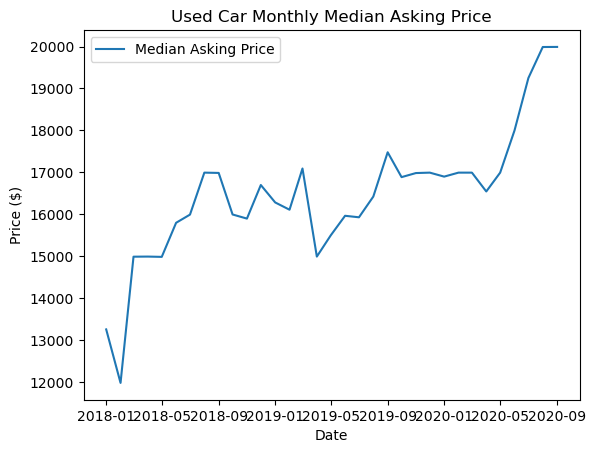

In [3]:
# visualize the time series
plt.plot(data['Price'], label='Median Asking Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.title('Used Car Monthly Median Asking Price')
plt.show();

### Train/Test Split

In [4]:
# 80/20 train test split
train_size = int(.8 * len(data))
train_data = data[:train_size]
test_data = data[train_size:]

# put the y feature in arrays
y_train = np.array(train_data['Price']).reshape(-1,1)
y_test = np.array(test_data['Price']).reshape(-1,1)
print(y_train.shape)
print(y_test.shape)

(26, 1)
(7, 1)


### ACF and PACF Plots

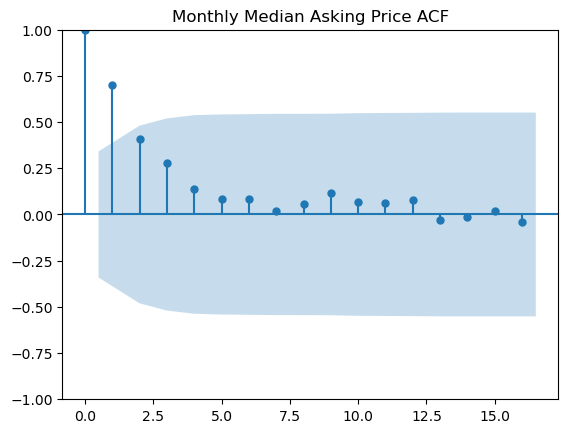

In [5]:
# acf plot
plot_acf(data['Price'], title = 'Monthly Median Asking Price ACF')
plt.show();

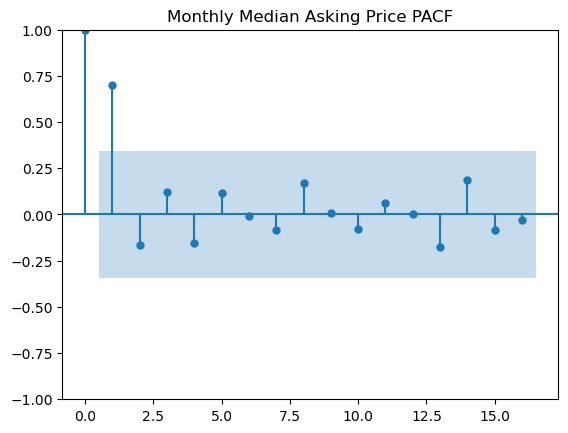

In [6]:
# pacf plot
plot_pacf(data['Price'], title = 'Monthly Median Asking Price PACF')
plt.show();

### Fitting ARIMA(1,1,0) Model using `statsmodels`

In [7]:
# fit ARIMA(1,1,0) based on the ACF/PACF diagnostics
arima_model = ARIMA(y_train, order=(1, 1, 0))
arima_results = arima_model.fit()

# summary of the model
arima_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   26
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -204.126
Date:                Thu, 16 Apr 2026   AIC                            412.252
Time:                        22:16:24   BIC                            414.690
Sample:                             0   HQIC                           412.928
                                 - 26                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2541      0.251     -1.012      0.312      -0.746       0.238
sigma2      7.464e+05   2.39e+05      3.120      0.002    2.78e+05    1.22e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 6.47
Prob(Q):                              0.95   Prob(JB):                         0.04
Heteroskedasticity (H):               0.18   Skew:                             0.36
Prob(H) (two-sided):                  0.03   Kurtosis:                         5.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [8]:
# the predictions
arima_pred = arima_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data = pd.DataFrame({'Date': test_data.index, 'pred Price': arima_pred.flatten()})
pred_data.set_index('Date', inplace = True)
pred_data.head()

,pred Price
Date,
2020-03-01,16970.863141
2020-04-01,16976.995646
2020-05-01,16975.437547
2020-06-01,16975.833416
2020-07-01,16975.732837


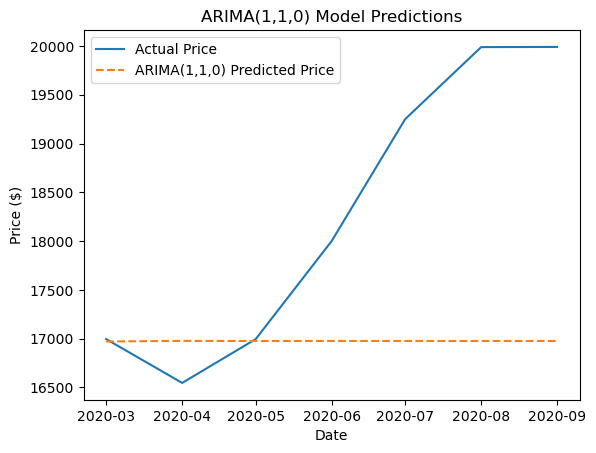

In [9]:
# make the plot
plt.plot(test_data['Price'], label = 'Actual Price')
plt.plot(pred_data['pred Price'], label = 'ARIMA(1,1,0) Predicted Price', linestyle = '--')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.title('ARIMA(1,1,0) Model Predictions')
plt.show();

### What about adding an MA term?

In [10]:
arima_model2 = ARIMA(y_train, order=(1, 1, 1))
arima_results2 = arima_model2.fit()

# summary of the model
arima_results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   26
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -203.386
Date:                Thu, 16 Apr 2026   AIC                            412.773
Time:                        22:16:24   BIC                            416.429
Sample:                             0   HQIC                           413.787
                                 - 26                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5553      0.289     -1.919      0.055      -1.122       0.012
ma.L1          0.3125      0.457      0.684      0.494      -0.583       1.208
sigma2       7.02e+05   2.42e+05      2.896      0.004    2.27e+05    1.18e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 1.19
Prob(Q):                              0.89   Prob(JB):                         0.55
Heteroskedasticity (H):               0.22   Skew:                            -0.10
Prob(H) (two-sided):                  0.05   Kurtosis:                         4.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
# the predictions
arima_pred2 = arima_results2.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)
pred_data2 = pd.DataFrame({'Date': test_data.index, 'pred Price': arima_pred2.flatten()})
pred_data2.set_index('Date', inplace = True)
pred_data2.head()

,pred Price
Date,
2020-03-01,16967.231326
2020-04-01,16982.650507
2020-05-01,16974.088660
2020-06-01,16978.842818
2020-07-01,16976.202965


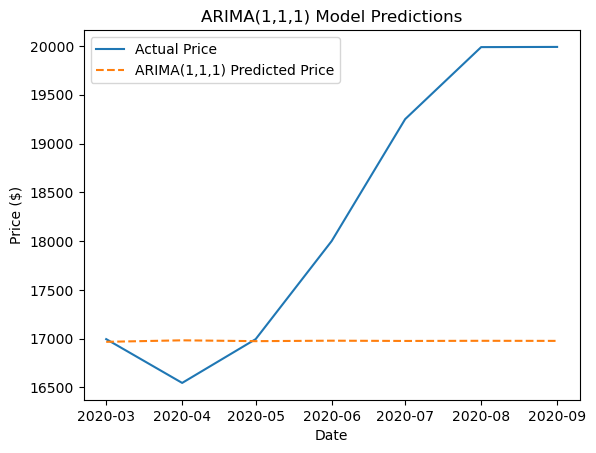

In [12]:
# make the plot
plt.plot(test_data['Price'], label = 'Actual Price')
plt.plot(pred_data2['pred Price'], label = 'ARIMA(1,1,1) Predicted Price', linestyle = '--')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.title('ARIMA(1,1,1) Model Predictions')
plt.show();

### Full History Plot

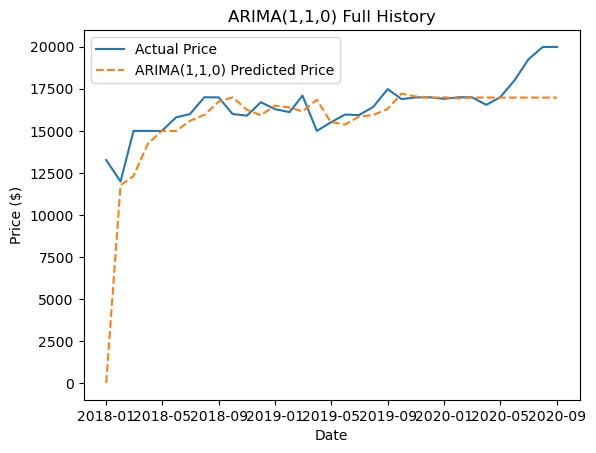

In [13]:
# plot the entire history with predictions
arima_pred_full = arima_results.predict(start=0, end=len(train_data) + len(test_data) - 1)
pred_full = pd.DataFrame({'Date': data.index, 'pred Price': arima_pred_full.flatten()})
pred_full.set_index('Date', inplace = True)

plt.plot(data['Price'], label = 'Actual Price')
plt.plot(pred_full['pred Price'], label = 'ARIMA(1,1,0) Predicted Price', linestyle = '--')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.title('ARIMA(1,1,0) Full History')
plt.show();

### Evaluation

In [14]:
# MAE on test set
mae = np.mean(np.abs(y_test.flatten() - arima_pred.flatten()))
print(mae)

1399.9454878907054
